<a href="https://colab.research.google.com/github/FaisalBinAbbas321/SWE485-Project/blob/main/Phase3_UnSupervised_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Phase 3 — UnSupervised Learning (Stroke Prediction)**

# **Phase Overview **

In this phase, we apply **unsupervised learning** (clustering) to the stroke dataset to:

- Discover **natural groups** (clusters) of patients based on their features.
- Use **clustering quality metrics**, such as:
  - **Silhouette Coefficient**
  - **Total Within-Cluster Sum of Squares (WCSS)**
  - **BCubed Precision & Recall** (using the existing `stroke` label as an external reference)
- Use **visualizations**  to understand the clusters.
- Discuss **how the discovered clusters can improve our supervised model** from previous phases  
  (e.g., better risk profiles, refined recommendations, or data insights).


In [2]:

# Core libraries
import numpy as np
import pandas as pd


import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

from sklearn.decomposition import PCA


In [5]:
# Load Dataset
DATA_PATH = "https://raw.githubusercontent.com/FaisalBinAbbas321/SWE485-Project/main/Dataset/Stroke-data.csv"

df = pd.read_csv(DATA_PATH)

df.head()

# Basic info
print("Shape:", df.shape)
display(df.head())

print("\nData types:")
print(df.dtypes)

print("\nMissing values per column:")
print(df.isnull().sum())


Shape: (5110, 12)


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1



Data types:
id                     int64
gender                object
age                  float64
hypertension           int64
heart_disease          int64
ever_married          object
work_type             object
Residence_type        object
avg_glucose_level    float64
bmi                  float64
smoking_status        object
stroke                 int64
dtype: object

Missing values per column:
id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64


## 3. Preprocessing for Clustering

Clustering works on **features only**, without labels.  

Our dataset columns:

- `id` → **Identifier**, no meaning for clustering → we will **drop** it.
- `stroke` → **Target label** (0/1) used in previous supervised phases →  
  - We **remove it from X** before clustering.  
  - We **keep it as `y`** to evaluate clusters (BCubed precision/recall).
### 3.1. Feature Groups

- **Numeric features:**
  - `age`
  - `hypertension`
  - `heart_disease`
  - `avg_glucose_level`
  - `bmi`

- **Categorical features:**
  - `gender`
  - `ever_married`
  - `work_type`
  - `Residence_type`
  - `smoking_status`

### 3.2. Preprocessing Steps

1. **Drop** `id` column.
2. **Separate**:
   - `X` = features (no `stroke`, no `id`)
   - `y` = `stroke` (for external evaluation)
3. **Numeric pipeline:**
   - Impute missing values with **median**.
   - Scale with **StandardScaler**.
4. **Categorical pipeline:**
   - Impute missing values with **most frequent**.
   - Encode using **OneHotEncoder**.
5. Combine both using **ColumnTransformer**.

In [6]:

df_features = df.drop(columns=["id", "stroke"])
y = df["stroke"].values


numeric_features = ["age", "hypertension", "heart_disease", "avg_glucose_level", "bmi"]
categorical_features = ["gender", "ever_married", "work_type", "Residence_type", "smoking_status"]


numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])


categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])


preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)


X_preprocessed = preprocessor.fit_transform(df_features)

print("Original X shape:", df_features.shape)
print("Preprocessed X shape:", X_preprocessed.shape)


Original X shape: (5110, 10)
Preprocessed X shape: (5110, 21)


## 4. Choosing a Clustering Algorithm

We choose **K-Means** clustering for the following reasons:

- It is one of the most **popular and simple** clustering algorithms.
- Works well on **numerical** data, especially after scaling.
- Our preprocessed data is numeric (after one-hot encoding and scaling).
- We expect a relatively **small number of clusters** representing different
  **risk profiles** or **patient groups**.

However, K-Means has limitations:

- It assumes **spherical clusters** and similar cluster sizes.
- It is sensitive to **outliers** and **initialization**.


In [7]:

k_values = [2, 3, 4, 5, 6]

wcss_values = []
silhouette_values = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(X_preprocessed)


    wcss_values.append(kmeans.inertia_)


    sil_score = silhouette_score(X_preprocessed, cluster_labels)
    silhouette_values.append(sil_score)

    print(f"k = {k} | WCSS = {kmeans.inertia_:.2f} | Silhouette = {sil_score:.4f}")


k = 2 | WCSS = 32802.15 | Silhouette = 0.1567
k = 3 | WCSS = 27570.37 | Silhouette = 0.1960
k = 4 | WCSS = 23102.86 | Silhouette = 0.2336
k = 5 | WCSS = 20603.20 | Silhouette = 0.2379
k = 6 | WCSS = 19104.27 | Silhouette = 0.2105


We will start with K-Means and evaluate the clustering quality using:

- **Total Within-Cluster Sum of Squares (WCSS)** → "Elbow method"
- **Silhouette Score** → how well-separated and cohesive clusters are
- **BCubed Precision & Recall** → how well clusters align with the `stroke` label.

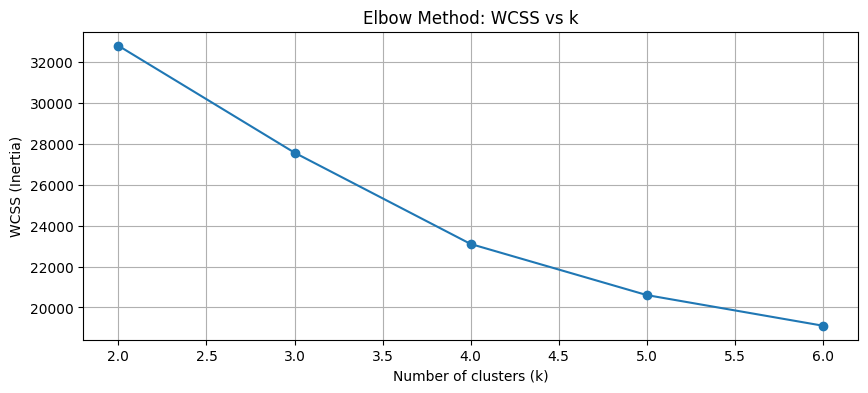

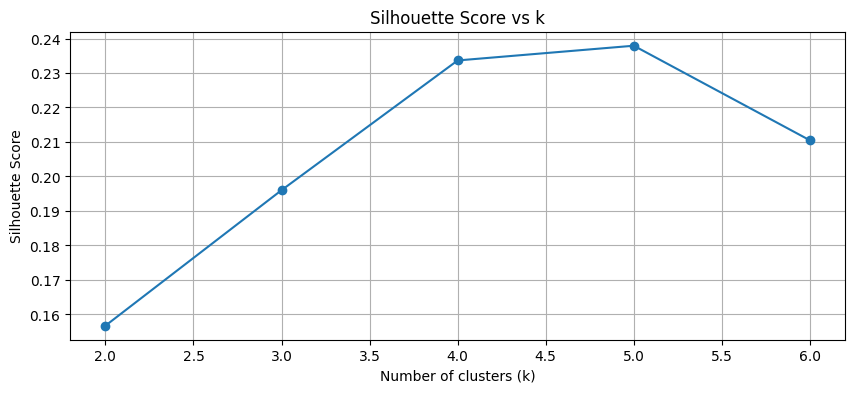

In [8]:

plt.figure(figsize=(10,4))
plt.plot(k_values, wcss_values, marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("WCSS (Inertia)")
plt.title("Elbow Method: WCSS vs k")
plt.grid(True)
plt.show()

plt.figure(figsize=(10,4))
plt.plot(k_values, silhouette_values, marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score vs k")
plt.grid(True)
plt.show()


## 5. Final K-Means Model (Chosen k)

Based on the **Elbow** and **Silhouette** plots, we select a value of **k** that:

- Shows a clear “elbow” in the WCSS curve.
- Has a relatively **high silhouette score** compared to other k values.
- Makes sense **clinically / logically** (e.g., 2–3 patient groups).

> For this notebook, we will assume **k = 2** to create two major patient clusters

In [9]:

best_k = 2

kmeans_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
cluster_labels_final = kmeans_final.fit_predict(X_preprocessed)

df_with_clusters = df.copy()
df_with_clusters["cluster"] = cluster_labels_final

df_with_clusters[["age", "avg_glucose_level", "bmi", "stroke", "cluster"]].head()


,age,avg_glucose_level,bmi,stroke,cluster
0,67.0,228.69,36.6,1,0
1,61.0,202.21,NaN,1,0
2,80.0,105.92,32.5,1,0
3,49.0,171.23,34.4,1,0
4,79.0,174.12,24.0,1,0


## 6. BCubed Precision and Recall

Although clustering is **unsupervised**, we already have a known label: `stroke`.

We can use `stroke` as an **external reference** to measure how well the clusters
match the actual classes.

**BCubed Precision & Recall**:

- For each data point:
  - **Precision**: How many items in the same cluster share the same true label?
  - **Recall**: How many items with the same true label are in this item’s cluster?
- We average these over all points.

These metrics are often used in **clustering evaluation** when the “ground truth”
labels are known.


In [10]:
from collections import defaultdict

def bcubed_precision_recall(true_labels, cluster_labels):
    """
    Compute BCubed precision and recall.
    true_labels: array-like of shape (n_samples,)
    cluster_labels: array-like of shape (n_samples,)
    """
    n = len(true_labels)
    label_indices = defaultdict(list)
    cluster_indices = defaultdict(list)


    for i, (y, c) in enumerate(zip(true_labels, cluster_labels)):
        label_indices[y].append(i)
        cluster_indices[c].append(i)

    precision_sum = 0.0
    recall_sum = 0.0

    for i in range(n):
        y = true_labels[i]
        c = cluster_labels[i]

        same_class = set(label_indices[y])
        same_cluster = set(cluster_indices[c])
        intersection = same_class & same_cluster


        precision_i = len(intersection) / len(same_cluster) if len(same_cluster) > 0 else 0.0
        recall_i = len(intersection) / len(same_class) if len(same_class) > 0 else 0.0

        precision_sum += precision_i
        recall_sum += recall_i

    precision = precision_sum / n
    recall = recall_sum / n
    return precision, recall


bcubed_prec, bcubed_rec = bcubed_precision_recall(y, cluster_labels_final)
bcubed_f1 = 2 * bcubed_prec * bcubed_rec / (bcubed_prec + bcubed_rec)

print(f"BCubed Precision: {bcubed_prec:.4f}")
print(f"BCubed Recall:    {bcubed_rec:.4f}")
print(f"BCubed F1-score:  {bcubed_f1:.4f}")


BCubed Precision: 0.9093
BCubed Recall:    0.5756
BCubed F1-score:  0.7049


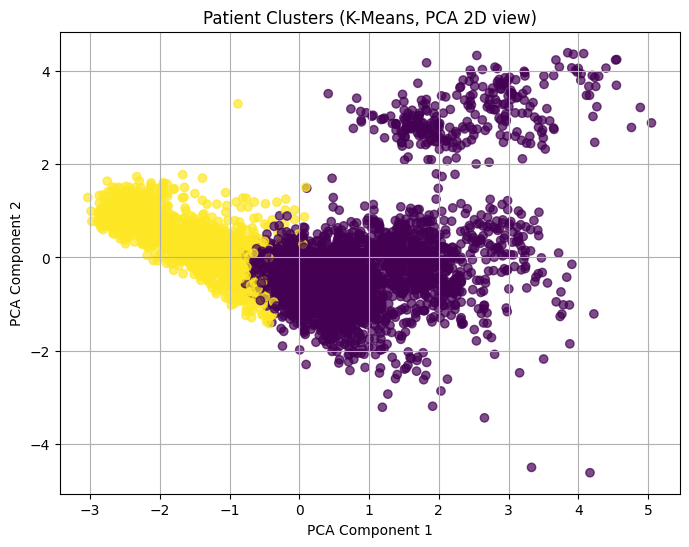

In [11]:
# (2D Visualization with PCA)
if hasattr(X_preprocessed, "toarray"):
    X_dense = X_preprocessed.toarray()
else:
    X_dense = X_preprocessed


pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X_dense)

plt.figure(figsize=(8,6))
scatter = plt.scatter(X_2d[:, 0], X_2d[:, 1], c=cluster_labels_final, alpha=0.7)
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("Patient Clusters (K-Means, PCA 2D view)")
plt.grid(True)
plt.show()


## 7. Cluster Interpretation and Integration with Supervised Model

### 7.1. Cluster Profiles

We can compute summary statistics per cluster to understand them:

- Average **age**
- Average **BMI**
- Average **glucose**
- Proportion of patients with **stroke = 1** in each cluster

Example interpretation (you will adjust based on your actual results):

- **Cluster 0**:
  - Older average age, higher BMI, higher glucose
  - Higher percentage of stroke cases
  - → Might represent **higher-risk patients**

- **Cluster 1**:
  - Younger average age, lower BMI, more normal glucose
  - Lower percentage of stroke cases
  - → Might represent **lower-risk patients**

### 7.2. How Clustering Can Improve the Supervised Model

The discovered clusters can be used in several ways:

1. **Add cluster ID as a new feature**  
   - Train your previous supervised model again (Phase 1 & 2) but add the `cluster` column.
   - The model can learn **different patterns** for different subgroups.

2. **Design different decision thresholds per cluster**  
   - For high-risk clusters, use a **lower probability threshold** to trigger "stroke risk" warning.
   - For low-risk clusters, use a higher threshold to avoid false alarms.

3. **Personalized Recommendations**  
   - Each cluster can be associated with a different style of advice:
     - Lifestyle changes (diet, activity)
     - Medical follow-ups
     - Monitoring frequency

4. **Data Insight**  
   - If clusters do not align well with `stroke` labels (low BCubed scores), this may indicate:
     - Hidden subgroups inside stroke / non-stroke patients.
     - The need to engineer additional features (e.g., age groups, combined risk scores).

If, after analysis, clustering does **not** provide useful separation or insight (e.g., low silhouette score, no meaningful pattern in cluster statistics), we can explain that:

- The dataset might not have strong **natural clusters**.
- The patient features might be better modeled directly by supervised learning rather than unsupervised groups.


## 8. Conclusion

In this Phase 3 (Unsupervised Learning), we:

- Applied **K-Means clustering** to the stroke dataset after:
  - Dropping `id`
  - Removing `stroke` from the input features
  - Handling missing values and encoding categorical features
- Evaluated the quality of clustering using:
  - **WCSS (Elbow method)**
  - **Silhouette Score**
  - **BCubed Precision & Recall** with respect to the true `stroke` label
- Visualized the clusters in **2D with PCA**.
- Interpreted cluster profiles and discussed how clustering can:
  - Enhance the **previous supervised model**
  - Provide **new insights** about patient groups
  - Support more **personalized recommendations**.
